In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
#  add light grid to adll figs
plt.rcParams.update({
        "text.usetex": False,          # disable system LaTeX
        "mathtext.fontset": "stix",    # nicer math font
        "font.family": "serif",
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "grid.color": "lightgray",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
    })

In [3]:
# theoretical recall @ 10 vs nprobe
# on SIFT/MSTuring Static sets
# surge & gp-ann
# TODO: compute imbalance information for both?

In [4]:
# gp-ann to generate: 
# 1. ./Partition - partitions 
# 2. ./QueryAttribution - query routes

# surge - to generate:
# 1. ./bin/theoretical_partitioning_quality
# 2. python nprobe_oracle.py to compute oracle results for recall target mode


# /dataset/big-ann-benchmarks/data/MSTuringANNS/gpann_partitions/
#       'msturing100M.k=10.GP'   query_attribution_msturing100M.routes
#   recalls: /dataset/big-ann-benchmarks/data/MSTuringANNS/gpann_partitions/recall_results.csv
# /dataset/big-ann-benchmarks/data/bigann/gpann_partitions/
#       'bigann100M.k=10.GP'   query_attribution_bigann100M.routes
#   recalls: /dataset/big-ann-benchmarks/data/bigann/gpann_partitions/recall_results.csv

In [5]:
msturing_gpann_path = "/dataset/big-ann-benchmarks/data/MSTuringANNS/gpann_partitions/recall_results.csv"
msturing_gpann = pd.read_csv(msturing_gpann_path)

bigann_gpann_path = "/dataset/big-ann-benchmarks/data/bigann/gpann_partitions/recall_results.csv"
bigann_gpann = pd.read_csv(bigann_gpann_path)

In [6]:
# surge results: (benchmarking sets)
# to generate: ./bin/theoretical_partitioning_quality.cpp
# /dataset/surge-dont_copy/theoretical_partition_quality_sift-500M_10_*
# /dataset/surge-dont_copy/theoretical_partition_quality_msturing-500M_10_*

# /dataset/surge/results/theoretical_partition_quality_sift-100M_10_20260519_105832
# /dataset/surge/results/theoretical_partition_quality_msturing-100M_10_20260519_105024

# sift/msturing 500M:
# /dataset/surge/results/theoretical_partition_quality_sift-500M_10_20260519_130459

In [10]:
msturing_surge_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-100M_10_20260520_130929/routing_metrics.csv"
msturing_surge_nprobeoracle_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-100M_10_20260520_130929/oracle_nprobe_results.csv"

msturing_surge = pd.read_csv(msturing_surge_path)
msturing_surge_oracle = pd.read_csv(msturing_surge_nprobeoracle_path)

bigann_surge_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_sift-100M_10_20260519_105832/routing_metrics.csv"
bigann_surge_nprobeoracle_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_sift-100M_10_20260519_105832/oracle_nprobe_results.csv"
bigann_surge = pd.read_csv(bigann_surge_path)
bigann_surge_oracle = pd.read_csv(bigann_surge_nprobeoracle_path)

In [11]:
# insert new row to msturing_surge
# AttributeError: 'DataFrame' object has no attribute 'append'
msturing_surge = pd.concat([msturing_surge, pd.DataFrame({"mode": ["nprobe"], 
                                        "param": [10], 
                                        "recall": [1.0], 
                                        "activation": [1.0], 
                                        "imbalance": [0]})], ignore_index=True)
bigann_surge = pd.concat([bigann_surge, pd.DataFrame({"mode": ["nprobe"], 
                                        "param": [10], 
                                        "recall": [1.0], 
                                        "activation": [1.0], 
                                        "imbalance": [0]})], ignore_index=True)

,nprobe,activation,mean_recall,p5_recall,p95_recall
0,1,0.1,0.69495,0.3,1.0
1,2,0.2,0.87683,0.6,1.0
2,3,0.3,0.95130,0.8,1.0
3,4,0.4,0.98402,0.9,1.0
4,5,0.5,0.99640,1.0,1.0
5,6,0.6,0.99944,1.0,1.0
6,7,0.7,0.99999,1.0,1.0
7,8,0.8,1.00000,1.0,1.0
8,9,0.9,1.00000,1.0,1.0
9,10,1.0,1.00000,1.0,1.0


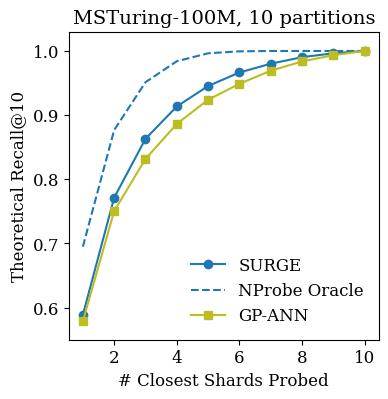

In [21]:
# set figure size
plt.figure(figsize=(4, 4))

plt.plot(msturing_surge[msturing_surge["mode"] == "nprobe"]["param"],
         msturing_surge[msturing_surge["mode"] == "nprobe"]["recall"], label="SURGE",
         marker="o")

plt.plot(msturing_surge_oracle['nprobe'][:10], 
         msturing_surge_oracle['mean_recall'][:10], 
         label="NProbe Oracle", color='C0', ls="--")

plt.plot(msturing_gpann["num_shards_searched"], 
         msturing_gpann["route_456_HNSW_HierKMeans"], label="GP-ANN", marker="s", color="C8")

# plt.plot(msturing_gpann["num_shards_searched"], 
#          msturing_gpann["num_shards_searched"]/10, label="Random Baseline", ls=":", color="black", alpha=0.3)

plt.xlabel("# Closest Shards Probed")
plt.ylabel("Theoretical Recall@10")
plt.title("MSTuring-100M, 10 partitions")
plt.legend(loc="lower right", frameon=False)

# plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# round yticks to 1 decimal place
plt.ylim(0.55, 1.03)


# save the figure
plt.savefig("msturing100_theoretical_recall_vs_nprobe.pdf", bbox_inches="tight")

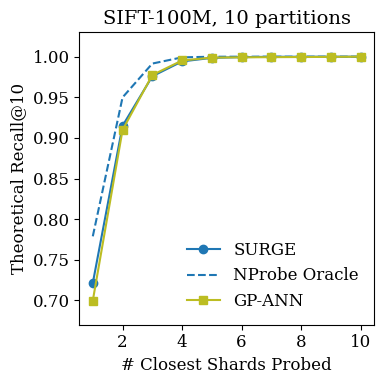

In [22]:
plt.figure(figsize=(4, 4))

plt.plot(bigann_surge[bigann_surge["mode"] == "nprobe"]["param"],
         bigann_surge[bigann_surge["mode"] == "nprobe"]["recall"], label="SURGE", marker="o")

plt.plot(bigann_surge_oracle['nprobe'][:10], 
         bigann_surge_oracle['mean_recall'][:10], 
         label="NProbe Oracle", color='C0', ls="--")

plt.plot(bigann_gpann["num_shards_searched"], 
         bigann_gpann["route_456_HNSW_HierKMeans"], label="GP-ANN", marker="s", color="C8")

# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
# round ylabels to 1 decimal place

plt.xlabel("# Closest Shards Probed")
plt.ylabel("Theoretical Recall@10")
plt.title("SIFT-100M, 10 partitions")
plt.legend(loc="lower right", frameon=False)

plt.ylim(0.67, 1.03)

# plt.yticks(np.round(plt.yticks()[0], decimals=1)) # this changes the ylimits, how do i round yticks without changing ylimits?
plt.tight_layout()
plt.savefig("sift100_theoretical_recall_vs_nprobe.pdf", bbox_inches="tight")

In [23]:
bigann_500M_surge_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_sift-500M_10_20260519_130459/routing_metrics.csv"
bigann_500M_surge_oracle_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_sift-500M_10_20260519_130459/oracle_nprobe_results.csv"

bigann_500M_surge = pd.read_csv(bigann_500M_surge_path)
bigann_500M_surge_oracle = pd.read_csv(bigann_500M_surge_oracle_path)

msturing_500M_surge_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-500M_10_20260520_133756/routing_metrics.csv"
msturing_500M_surge_oracle_path = "/dataset/surge/results/theoretical_partition_quality/theoretical_partition_quality_msturing-500M_10_20260520_133756/oracle_nprobe_results.csv"

msturing_500M_surge = pd.read_csv(msturing_500M_surge_path)
msturing_500M_surge_oracle = pd.read_csv(msturing_500M_surge_oracle_path)


In [24]:
bigann_500M_surge = pd.concat([bigann_500M_surge, pd.DataFrame({"mode": ["nprobe"], 
                                        "param": [10], 
                                        "recall": [1.0], 
                                        "activation": [1.0], 
                                        "imbalance": [0]})], ignore_index=True)
msturing_500M_surge = pd.concat([msturing_500M_surge, pd.DataFrame({"mode": ["nprobe"], 
                                        "param": [10], 
                                        "recall": [1.0], 
                                        "activation": [1.0], 
                                        "imbalance": [0]})], ignore_index=True)

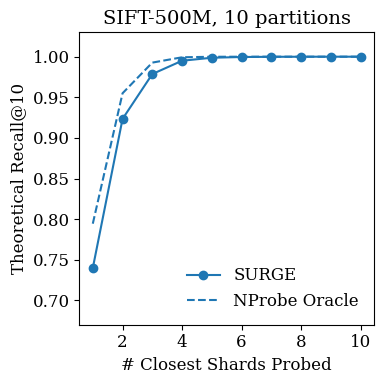

In [25]:
plt.figure(figsize=(4, 4))

plt.plot(bigann_500M_surge[bigann_500M_surge["mode"] == "nprobe"]["param"],
         bigann_500M_surge[bigann_500M_surge["mode"] == "nprobe"]["recall"], label="SURGE", marker="o")

plt.plot(bigann_500M_surge_oracle['nprobe'][:10], 
         bigann_500M_surge_oracle['mean_recall'][:10], 
         label="NProbe Oracle", color='C0', ls="--")

# plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.xlabel("# Closest Shards Probed")
plt.ylabel("Theoretical Recall@10")
plt.title("SIFT-500M, 10 partitions")
plt.legend(loc="lower right", frameon=False)

# plt.yticks(np.round(plt.yticks()[0], decimals=1))
plt.tight_layout()
plt.ylim(0.67, 1.03)

plt.savefig("sift500_theoretical_recall_vs_nprobe.pdf", bbox_inches="tight")

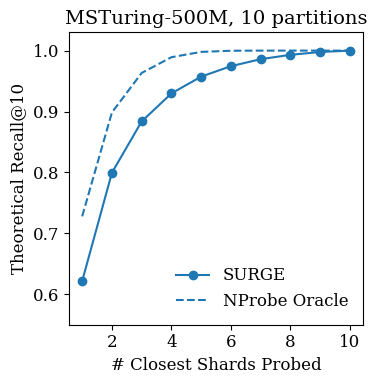

In [26]:
plt.figure(figsize=(4, 4))

plt.plot(msturing_500M_surge[msturing_500M_surge["mode"] == "nprobe"]["param"],
         msturing_500M_surge[msturing_500M_surge["mode"] == "nprobe"]["recall"], label="SURGE", marker="o")

plt.plot(msturing_500M_surge_oracle['nprobe'][:10], 
         msturing_500M_surge_oracle['mean_recall'][:10], 
         label="NProbe Oracle", color='C0', ls="--")
# plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.xlabel("# Closest Shards Probed")
plt.ylabel("Theoretical Recall@10")
plt.title("MSTuring-500M, 10 partitions")
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.ylim(0.55, 1.03)

plt.savefig("msturing500_theoretical_recall_vs_nprobe.pdf", bbox_inches="tight")